# Universidad de Buenos Aires
# Aprendizaje Profundo - TP3
# Cohorte 25 - 3er bimestre 2026


## **Alumno 1:** Franco Marcelo Morero

Este tercer y último TP se debe entregar hasta las **23:59hs del martes 25 de agosto (hora de Argentina)**.

La resolución del TP se puede hacer en **parejas** o de forma **individual**.

Pueden utilizar los contenidos vistos en clase y otra bibliografía que consideren que les haga falta. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP3 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/4gQ7iQQyJd2tn4Mb9)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP3.
- Renombrar el archivo de la siguiente manera: **PRIMERAPELLIDOALUMNO1-PRIMERNOMBREALUMNO1-PRIMERAPELLIDOALUMNO2-PRIMERNOMBREALUMNO2-TP3-Co25.ipynb**
O en caso hacerlo individual usar: **PRIMERAPELLIDO-PRIMERNOMBRE-TP3-Co25.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- No ocultar celdas, todas se deben poder ver desde el inicio.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **CLASIFICADOR DE EMOCIONES**

El objetivo de este trabajo es construir una red neuronal convolucional (CNN) utilizando Pytorch, capaz de clasificar emociones humanas a partir de imágenes faciales. El clasificador deberá identificar una de las 7 emociones básicas: alegría, tristeza, enojo, miedo, sorpresa, disgusto y seriedad. El dataset se encuentra en este link: https://drive.google.com/file/d/1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT/view?usp=sharing

In [ ]:
import os
from pathlib import Path

# en local el dataset ya está junto al notebook, en Colab se baja la primera vez.
if not os.path.exists("datos_zip/dataset_emociones/train"):
    %pip install -q gdown
    import gdown
    import zipfile
    gdown.download("https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT", "archivo.zip", quiet=False)
    os.makedirs("datos_zip", exist_ok=True)
    with zipfile.ZipFile("archivo.zip", "r") as zip_ref:
        zip_ref.extractall("datos_zip")
    print("Dataset descargado")


DATASET_ROOT_TRAIN = Path("datos_zip/dataset_emociones/train")
DATASET_ROOT_VAL = Path("datos_zip/dataset_emociones/validation")

assert DATASET_ROOT_TRAIN.exists() and DATASET_ROOT_VAL.exists()
print(f"train      -> {DATASET_ROOT_TRAIN.resolve()}")
print(f"validation -> {DATASET_ROOT_VAL.resolve()}")

Downloading...
From (original): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT
From (redirected): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT&confirm=t&uuid=e1e1109a-a7bc-4d4b-9a14-70c4fa9bb971
To: /Users/francomorero/PycharmProjects/franco/ceia-trabajos/aprendizaje_profundo/tps/archivo.zip
100%|██████████| 40.0M/40.0M [00:04<00:00, 8.95MB/s]


## 1. Preprocesamiento de Datos (2 puntos)

Antes de entrenar el modelo, se debe analizar qué tipo de preprocesamiento se debe aplicar a las imágenes. Para esto, se puede considerar uno o más aspectos como:

- Tamaño
- Relación de aspecto
- Color o escala de grises
- Cambio de dimensionalidad
- Normalización
- Balanceo de datos
- Data augmentation
- etc.

Sean criteriosos y elijan solo las técnicas que consideren pertinentes para este caso de uso en específico.

Recomendación: usar `torchvision.transforms` para facilitar el preprocesamiento. Lean su documentación si tienen dudas: https://docs.pytorch.org/vision/0.14/transforms.html



In [ ]:
import random

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from PIL import Image

from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid")

### Análisis exploratorio

Antes de decidir el preprocesamiento miro cuántas imágenes hay por emoción en cada split. Esto me sirve para verificar que las 7 clases estén presentes tanto en train como en validation, y para detectar desbalanceo, que condiciona decisiones posteriores como la eleccion de la función de costo y la metrica a optimizar.

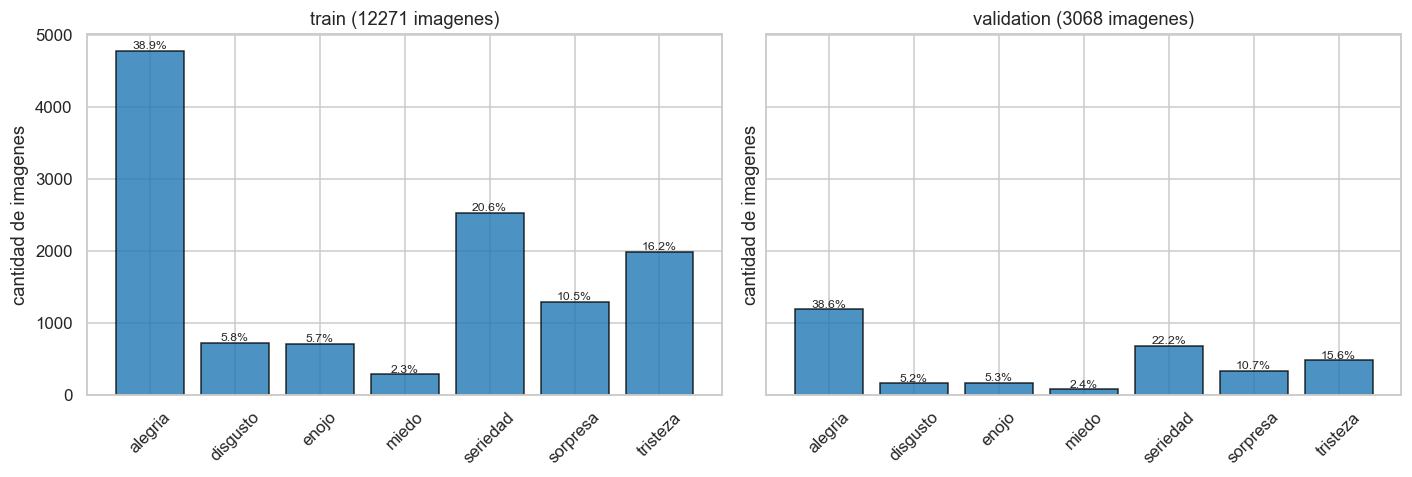

In [3]:
def contar_imagenes(root):
    return {d.name: len(list(d.glob("*.jpg"))) for d in sorted(root.iterdir()) if d.is_dir()}

conteo_train = contar_imagenes(DATASET_ROOT_TRAIN)
conteo_val = contar_imagenes(DATASET_ROOT_VAL)
EMOCIONES = list(conteo_train.keys())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (nombre, conteo) in zip(axes, [("train", conteo_train), ("validation", conteo_val)]):
    total = sum(conteo.values())
    barras = ax.bar(conteo.keys(), conteo.values(), color="tab:blue", edgecolor="black", alpha=0.8)
    for b, cant in zip(barras, conteo.values()):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{cant / total * 100:.1f}%",
                ha="center", va="bottom", fontsize=8)
    ax.set_title(f"{nombre} ({total} imagenes)")
    ax.set_ylabel("cantidad de imagenes")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Observaciones:**

- El dataset esta desbalanceado, con mas imagenes de alegria que las demas. Miedo es apenas un 2.3% y alegria es un 38.9%. Enojo y disgusto también tienen poco, apenas un ~5.7%.
- Train y validation comparten la misma distribución (validation es un 20% estratificado de cada clase), así que lo que el modelo vea en entrenamiento es representativo de cómo se lo va a evaluar.
- Con este desbalanceo se podria usar F1 macro, porque por ejemplo con accuracy solo, un modelo que responde siempre alegría ya saca casi 39%.

Ahora miro las imágenes en sí. Tomo 5 ejemplos al azar de cada emoción para entender con qué material estoy trabajando, qué tamaño tienen, si vienen en color y cómo están encuadrados los rostros.

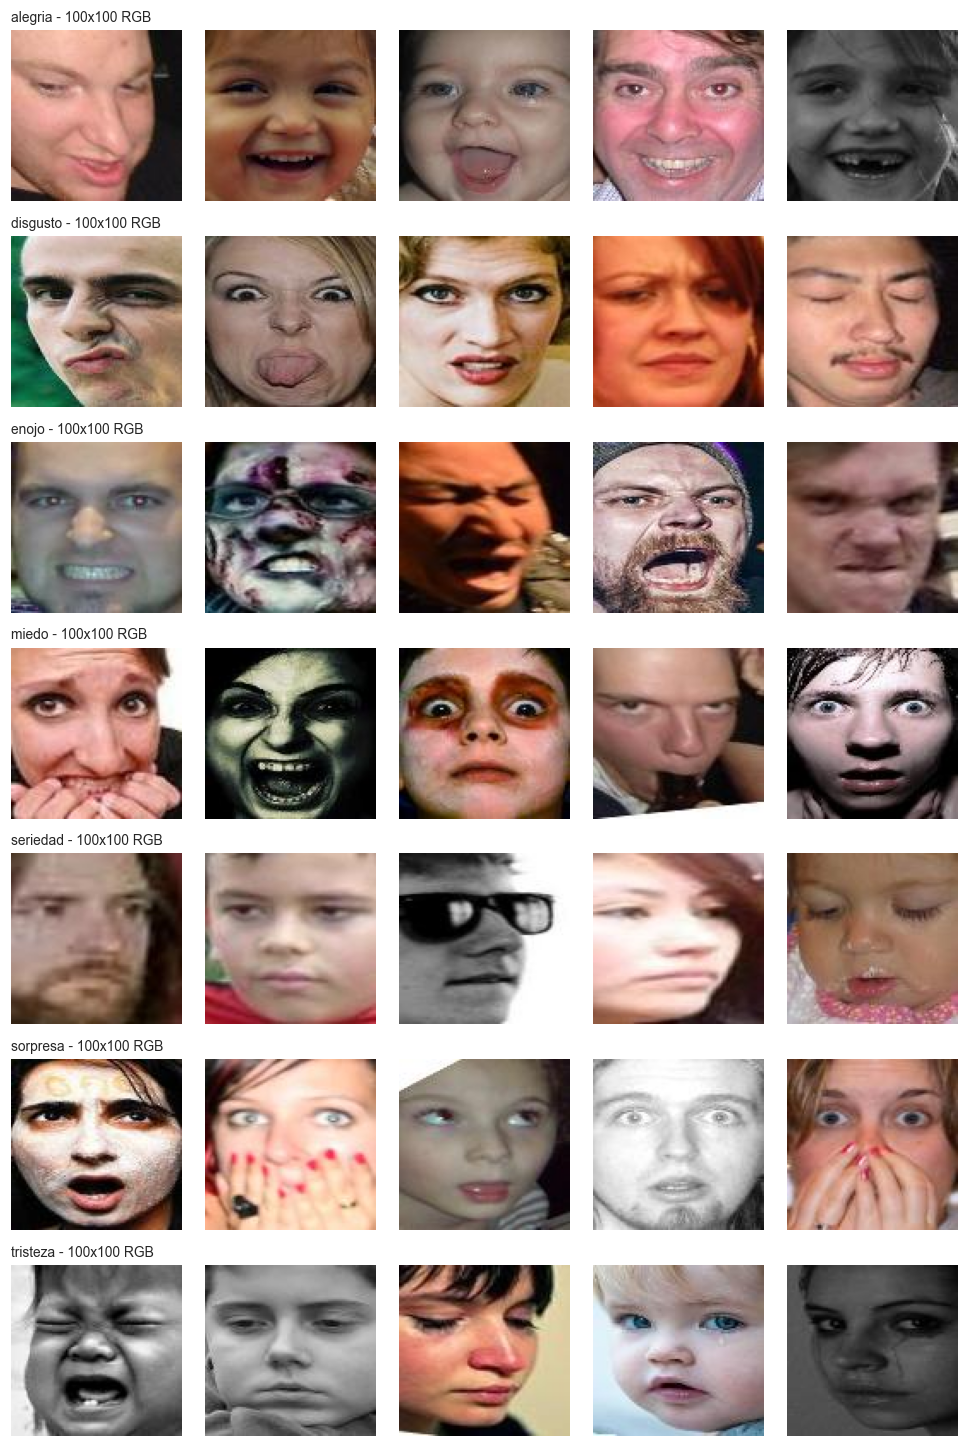

In [4]:
N_MUESTRAS = 5
fig, axes = plt.subplots(len(EMOCIONES), N_MUESTRAS, figsize=(9, 1.9 * len(EMOCIONES)))
for fila, emocion in enumerate(EMOCIONES):
    archivos = random.sample(sorted((DATASET_ROOT_TRAIN / emocion).glob("*.jpg")), N_MUESTRAS)
    for col, archivo in enumerate(archivos):
        img = Image.open(archivo)
        axes[fila, col].imshow(img)
        axes[fila, col].axis("off")
    axes[fila, 0].set_title(f"{emocion} - {img.size[0]}x{img.size[1]} {img.mode}", loc="left", fontsize=9)
plt.tight_layout()
plt.show()

In [5]:
# Chequeo rápido sobre una muestra grande: tamaños, modos y cuántas imágenes tienen color real
muestras = random.sample(sorted(DATASET_ROOT_TRAIN.rglob("*.jpg")), 1000)
tamanos, modos, grises = set(), set(), 0
for ruta in muestras:
    arr = np.array(Image.open(ruta))
    tamanos.add(arr.shape)
    modos.add(Image.open(ruta).mode)
    if arr.ndim == 3 and (arr[..., 0] == arr[..., 1]).all() and (arr[..., 1] == arr[..., 2]).all():
        grises += 1
print(f"formas encontradas      -> {tamanos}")
print(f"modos encontrados       -> {modos}")
print(f"imagenes con color real -> {100 * (1 - grises / len(muestras)):.1f}%")

formas encontradas      -> {(100, 100, 3)}
modos encontrados       -> {'RGB'}
imagenes con color real -> 89.0%


**Observaciones:**

- Todas las imágenes son de 100x100 y ya vienen cuadradas, la relación de aspecto no es un problema y no hace falta recortar ni agregar padding.
- Los rostros vienen alineados y centrados (los archivos se llaman `*_aligned.jpg`) y ocupan casi todo el cuadro, no necesito detección de rostros para entrenar.
- La gran mayoría tiene color real, no son fotos grises guardadas en RGB. En la muestra de 1000 solo un poco más del 10% tiene los tres canales idénticos.

### Elección del preprocesamiento

Con lo que vi arriba defino el pipeline:

- **Color:** Mantengo los 3 canales RGB. La gran mayoría de las imágenes tiene color real y si paso a escala de grises perderia informacion.
- **Tamaño y relación de aspecto:** Mantengo los 100x100 nativos. Las imágenes ya son cuadradas y uniformes, achicarlas solo perdería detalle. Dejo un `Resize((100, 100))` explícito en el pipeline porque despues queremos procesar mas imagenes que no esten en este dataset.
- **Escalado a [0, 1]:** Convierto los píxeles de enteros entre 0 y 255 a float32 entre 0 y 1, el rango con el que trabajan cómodas las capas convolucionales y el optimizador.
- **Flip horizontal, solo en train:** Una cara espejada expresa la misma emoción, es el augmentation que aparece en toda la literatura del tema. Ayuda especialmente a las clases chicas como miedo.
- **Rotación de ±10°, solo en train:** Simula pequeñas variaciones de pose y encuadre. La dejo leve a propósito, los rostros ya vienen alineados y una rotación fuerte generaría poses que en validación no existen.

En validation no aplico augmentation porque ahí quiero evaluar siempre sobre las mismas imágenes. 

In [ ]:
IMG_SIZE = 100
BATCH_SIZE = 64

transform_train = v2.Compose([
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(degrees=10),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

transform_val = v2.Compose([
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

train_dataset = datasets.ImageFolder(DATASET_ROOT_TRAIN, transform=transform_train)
val_dataset = datasets.ImageFolder(DATASET_ROOT_VAL, transform=transform_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

CLASES = train_dataset.classes
print(f"clases     -> {CLASES}")
print(f"train      -> {len(train_dataset)} imagenes, {len(train_loader)} batches")
print(f"validation -> {len(val_dataset)} imagenes, {len(val_loader)} batches")

clases     -> ['alegria', 'disgusto', 'enojo', 'miedo', 'seriedad', 'sorpresa', 'tristeza']
train      -> 12271 imagenes, 192 batches
validation -> 3068 imagenes, 48 batches


### Verificación del pipeline

Antes de dar por cerrado el preprocesamiento miro qué le llega efectivamente a la red. Muestro algunas imágenes originales junto a su versión transformada (con el augmentation aplicado, así que alguna puede aparecer espejada o levemente rotada) y chequeo la forma, el tipo y el rango del batch que entrega el `DataLoader`. 

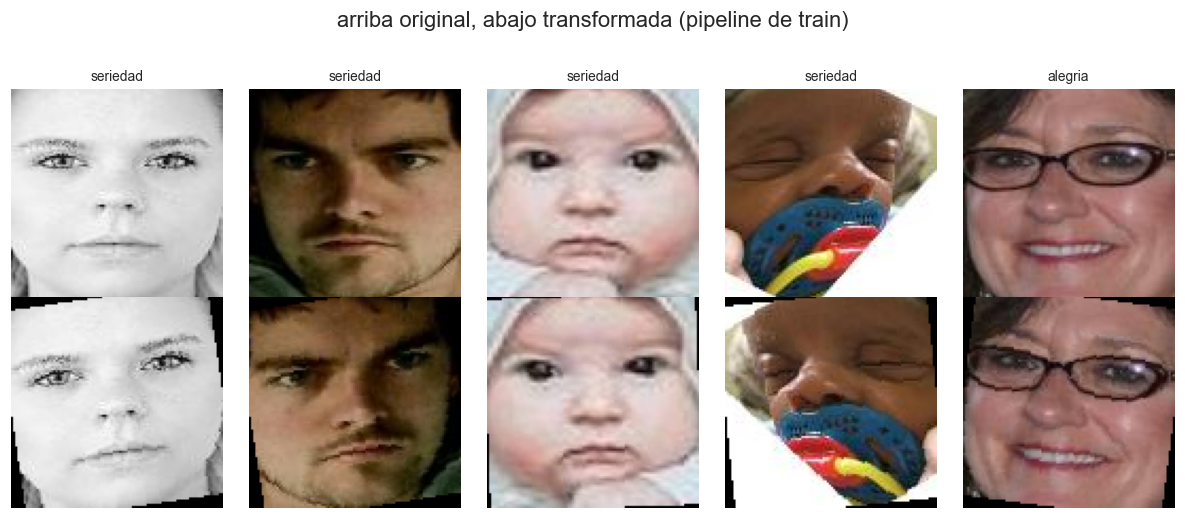

shape del batch -> (64, 3, 100, 100)
dtype           -> torch.float32
rango           -> [0.000, 1.000]


In [7]:
N_EJEMPLOS = 5
indices = random.sample(range(len(train_dataset)), N_EJEMPLOS)

fig, axes = plt.subplots(2, N_EJEMPLOS, figsize=(11, 4.8))
for col, idx in enumerate(indices):
    ruta, etiqueta = train_dataset.samples[idx]
    img_transformada, _ = train_dataset[idx]

    axes[0, col].imshow(Image.open(ruta))
    axes[0, col].set_title(CLASES[etiqueta], fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(img_transformada.permute(1, 2, 0))
    axes[1, col].axis("off")

fig.suptitle("arriba original, abajo transformada (pipeline de train)")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

imagenes, etiquetas = next(iter(train_loader))
print(f"shape del batch -> {tuple(imagenes.shape)}")
print(f"dtype           -> {imagenes.dtype}")
print(f"rango           -> [{imagenes.min():.3f}, {imagenes.max():.3f}]")

### ¿Alcanza con esto o necesitamos algo más?

Para contrastar mis decisiones revisé tres trabajos sobre reconocimiento de emociones faciales con CNNs, [Alizadeh y Fazel, 2017 (arXiv 1704.06756)](https://arxiv.org/abs/1704.06756), [Lonkar, 2021 (arXiv 2107.08640)](https://arxiv.org/abs/2107.08640) y Govindwar et al., 2024 (IJSRCSEIT vol 10). Los tres trabajan sobre FER2013 y de la comparación salen algunas conclusiones útiles.

- **Augmentation.** El flip horizontal aparece en los tres. Alizadeh y Fazel usan solamente flip y llegan a 64% de test, Lonkar suma rotaciones, zoom y brillo y llega a 70%, mientras que Govindwar usa flip y rotación pero no maneja el desbalanceo y se queda en 49% con un overfitting enorme. Mi lectura es que un augmentation moderado suma, pero lo que más pesa es qué se hace con el desbalanceo. Con flip más rotación leve quedo en línea con los que mejor resultado obtienen.
- **Desbalanceo.** Lonkar, el de mejor resultado, pondera la función de costo con pesos inversamente proporcionales a la cantidad de muestras por clase. Los otros dos no lo manejan y se les nota en las métricas por clase. Acá tengo dos opciones, un [`WeightedRandomSampler`](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.WeightedRandomSampler) que sobremuestrea las clases chicas al armar los batches, o pesos por clase en [`CrossEntropyLoss`](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html). Me quedo con los pesos en la loss. Con solo 281 imágenes de miedo el sampler repetiría las mismas caras una y otra vez invitando al overfitting sobre esa clase, mientras que los pesos logran el mismo efecto de balanceo sin tocar la distribución de los datos y son una línea de código. Lo aplico en el punto 2.
- **Normalización con media y desvío.** Podría restar la media del dataset y dividir por el desvío en lugar de dejar los valores en [0, 1] (Alizadeh y Fazel restan la media de train, Govindwar escala a [0, 1] como yo). Con BatchNorm dentro de la red, que es lo que pienso usar en el punto 2, la ganancia de normalizar la entrada es marginal, así que me quedo con el escalado simple.

También hay técnicas que descarto a propósito.

- **Flip vertical.** Una cara dada vuelta no es una muestra plausible del dominio y rompe la geometría cejas-ojos-boca que codifica la emoción.
- **Distorsiones fuertes, afines o elásticas.** La señal de la emoción vive en deformaciones sutiles de boca y cejas, una distorsión agresiva puede convertir una expresión en otra, es decir cambiarle la etiqueta real a la imagen.
- **Jitter de color fuerte.** El tono de piel no codifica la emoción y perturbarlo mucho solo mete ruido. Ninguno de los papers lo reporta como ganancia (Lonkar toca apenas el brillo).
- **Alineación de rostros o ecualización de histograma.** Ninguno de los tres papers lo hace y en este dataset los rostros ya vienen alineados de fábrica.

Mi conclusión es que el preprocesamiento queda cerrado con el resize de salvaguarda, el escalado a [0, 1] y el flip más rotación leve en train, y que el desbalanceo, que es el problema real de este dataset, se resuelve en el punto 2 con pesos por clase en la función de costo.

## 2. Construcción y entrenamiento del Modelo CNN (3.5 puntos)

- Construir una red neuronal convolucional con PyTorch, **sin usar modelos pre-entrenados**.
- Analizar correctamente qué funciones de activación se deben usar en cada etapa de la red, el learning rate a utilizar, la función de costo y el optimizador.
- Cosas como el número de capas, neuronas, número y tamaño de los kernels, entre otros, queda a criterio de ustedes, pero deben estar justificadas.

## 3. Evaluación del Modelo (2.5 puntos)

El modelo entrenado debe ser evaluado utilizando las siguientes métricas:

- **Accuracy**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **F1 Score Macro**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **Costo (Loss)**:
  - Mostrar una gráfica de evolución del costo por época para entrenamiento y validación.

- **Classification report**
  - Mostrar la precisión, recall y F1 score por cada clase usando `classification_report`

- **Matriz de confusión**:
  - Mostrar la matriz de confusión absoluta (valores enteros).
  - Mostrar la matriz de confusión normalizada (valores entre 0 y 1 por fila).

Se recomienda utilizar `scikit-learn` para calcular métricas como accuracy, F1 score, el Classification report y las matrices de confusión. Las visualizaciones pueden realizarse con `matplotlib` o `seaborn`.


 ## 4. Prueba de Imágenes Nuevas (1 punto)
Subir al menos 12 imágenes personales de cualquier ratio o relación de aspecto (pueden usar fotos del rostro de ustedes, rostros de personas generadas por IA o imágenes stock de internet), que no formen parte del dataset de entrenamiento ni de validación. Tampoco vale usar imágenes de otro dataset, deben ser imágenes sueltas.

- Debe haber al menos una imagen para cada emoción.

- Aplicar el mismo pre-procesamiento que se usó para el dataset de validation durante el entrenamiento del modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:

  - La imagen original
  - La imagen pre-procesada (mismas transformaciones que durante el entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase ganadora inferida por el modelo

- Redactar conclusiones preliminares

 ## 5. Prueba de Imágenes Nuevas con Pre-procesamiento Adicional (1 punto)
Las 12 imágenes del punto 4, ahora serán pasadas y recortadas por un algoritmo de detección de rostros. Usen el siguiente código para realizar un pre-procesamiento inicial de la imagen y ya luego aplican el pre-procesamiento que usaron al momento de entrenar el modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:
  - La imagen original
  - La imagen recortada por el algoritmo
  - La imagen pre-procesada (mismas transformaciones del entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase esperada
  - La clase ganadora inferida por el modelo

- Analizar los casos en los que el modelo se equivoca e intentar identificar posibles causas, tales como:

  - Similitudes entre emociones.
  - Mezcla de 2 o más emociones en una misma expresión.

- Comparar los resultados con el punto 4 y redactar conclusiones finales.

**IMPORTANTE:** Ajusten los parámetros `scaleFactor`, `minNeighbors` y `minSize` según convenga para que la detección de rostros sea más efectiva y logre detectar rostros en sus 12 imágenes. No se queden necesariamente con los valores por defecto.

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

image_path = ""

image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=6, minSize=(30,30))

image_with_box = image.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(image_with_box, (x, y), (x + w, y + h), (0, 255, 0), 2)

cropped_face_rgb = None
if len(faces) > 0:
    (x, y, w, h) = faces[0]
    center_x, center_y = x + w // 2, y + h // 2
    side = max(w, h)
    half_side = side // 2

    x1 = max(center_x - half_side, 0)
    y1 = max(center_y - half_side, 0)
    x2 = min(center_x + half_side, image.shape[1])
    y2 = min(center_y + half_side, image.shape[0])

    cropped_face = image[y1:y2, x1:x2]
    cropped_face_rgb = cv2.cvtColor(cropped_face, cv2.COLOR_BGR2RGB)

image_with_box_rgb = cv2.cvtColor(image_with_box, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image_with_box_rgb)
ax[0].set_title("Detección")
ax[0].axis('off')

if cropped_face_rgb is not None:
    ax[1].imshow(cropped_face_rgb)
    ax[1].set_title("Rostro recortado (relación aspecto 1:1)")
    ax[1].axis('off')
else:
    ax[1].text(0.5, 0.5, 'No se detectó rostro', horizontalalignment='center', verticalalignment='center')
    ax[1].axis('off')

plt.tight_layout()
plt.show()
